# Лабораторна 2. Від сирих даних до нейромережі

У цій лабораторній роботі ви пройдете повний цикл роботи з табличним датасетом для задачі регресії — від завантаження до порівняння моделей:

- дослідницький аналіз даних (EDA): загальний огляд, гістограми, кореляції;
- обробка пропусків і викидів;
- інженерія ознак;
- baseline: множинна лінійна регресія;
- нейромережа — підбір архітектури, функцій активації, оптимізатора власними експериментами;
- чесне порівняння моделей на test за метриками регресії (MSE, RMSE, MAE, R²).

Демо-ноутбук з лекції 3-4 — основа, звертайтесь до нього як до довідника, коли щось незрозуміло.

## 0. Опрацюйте демо-ноутбук з лекції
Прогляньте пояснення ноутбуку і запустіть всі клітинки демо-ноутбуку (крім тих секцій, в яких вказано, що їх запускати не можна).
Після цього дайте тут відповідь на запитання:
1. Чому для заповнення пропусків було обрано метод kNN?
2. Чому при тренуванні лінійної регресії train і val порівнюються лише на основі MSE, а після тренування на основі багатьох функцій? Проекспериментуйте в межах тренування з вибором функції і поділіться результатами.
3. Які висновки після клітинки 2.6 в демо Ви можете зробити?
4. Поясни для чого потрібен baseline в лінійній регресії і як він вираховується? Що є baseline для нейронної мережі?
5. Продемонструй дію всіх функцій активації на графіку функцій, згенерувавши 1000 випадкових значень Х і порахувавши для них Y через ці функції.
6. Яким чином в нейронній мережі утворилася така кількість параметрів, яка вказана після виконання 3.3?
7. Чи оптимально вибрано кількість епох в 3.5?

### 0.1 Мої відповіді:
1. У випадках, якби ми відкидали, або імпутували записи з пустими клітинками ми могли б втратити важливі дані для навчання моделі чи "передбачити" неіснуючі математично (порахувавши медіанне значення і тд). При використанні kNN під час заповнення цих пустих даних, отримані нові значення обраховуються з урахуванням решти ознак рядка.
2. Ця функція має похідну в кожній своїй точці і є гладкою, що важливо для градієнтного спуску. Під час великих відхилень вона силько штрафує модель за великі відхилення, що змушує її активніше коригувати значні помилки. Функції, що використовуються після тренування вже відображають реальні одиниці виміру, що показує загальну адекватність моделі.  
Я протестував тренування моделі з функцією втрат HuberLoss і різниця між фінальними значеннями train_loss та val_loss була змінилася в два рази (з близько 0.53 до 0.24), проте фінальні метрики навпаки погіршилися (R^2 0.59 ->0.48, RMSE 0.74 -> 0.83) тому що train_loss та val_loss змінилися, лише через те, що функції втрат рахують їх по різному і не означають, що модель покращилася чи погіршилася.
3. Дані були приведені до одного масштабу завдаяки стандартизації ознак, тому їх вплив можна оцінити за абсолютним значенням ваги. Найвпливовіші ознаки: MedInc, diag_coord та bedperrom, найменш впливова для лінійної регресії була Population.
4. Бейзлайн потрібен для порівняння того чи змогла лінійна регресія краще передбачати свої відповіді після тренування, він є дуже простим алгоритмом (сережнє значення ціни) який і дає зрозуміти чи працює взагалі модель. Для нейронки ми беремо лінійну регресію як бейзлайн, бо першочергово вона є дуже простою і якщо складніша нейронка, не зможе побити просту лінійну регресію, то щось пішло не так.
5. Код нижче:

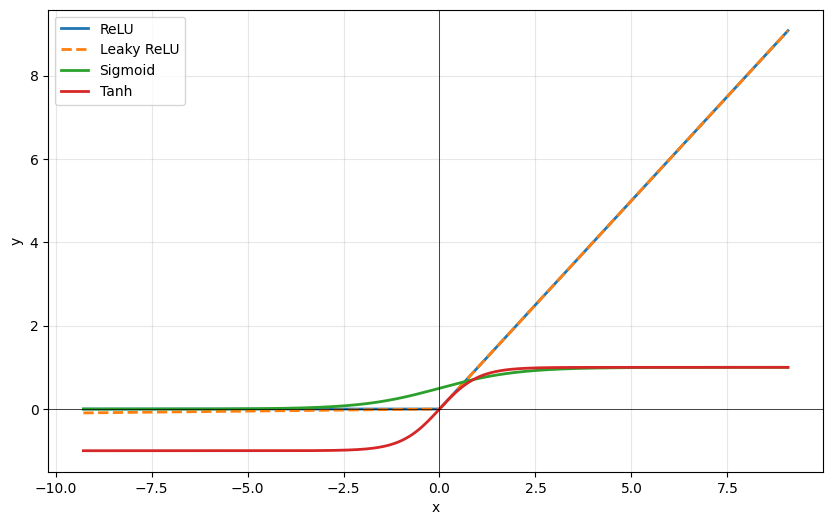

In [165]:
import torch
import matplotlib.pyplot as plt

x = torch.randn(1000) * 3
x, _ = torch.sort(x)

y_relu = torch.relu(x)
y_leaky_relu = torch.nn.functional.leaky_relu(x)
y_sigmoid = torch.sigmoid(x)
y_tanh = torch.tanh(x)

x_np = x.numpy()

plt.figure(figsize=(10, 6))
plt.plot(x_np, y_relu.numpy(), label="ReLU", linewidth=2)
plt.plot(x_np, y_leaky_relu.numpy(), label="Leaky ReLU", linewidth=2, linestyle="--")
plt.plot(x_np, y_sigmoid.numpy(), label="Sigmoid", linewidth=2)
plt.plot(x_np, y_tanh.numpy(), label="Tanh", linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

6. На демці у нас виходить 2625 параметрів. Ми будуємо нейронку за допомогою nn.Sequential і вона має 3 ланайні шари, у кожному шарі кількість нейронів вираховується наступним чином: кількість входів * кількість виходів + зміщення. З цього виходить наступне:
перший шар: Linear(n_features, 64) - 7 * 64 + 64 = 512;
другий шар: Linear(64, 32) - 64 * 32 + 32 = 2080;
третій шар: Linear(32, 1) - 32 * 1 + 1 = 33;
512 + 2080 + 33 = 2625 параметрів
7. На графіку кривої навчання видно, що train та val на останніх епохах ще продовжують повільно спадати і не входять в overfitting, тому в теорії їм ще є куди покращуватися, а моделі донавчатися, тому кількість епох обрана не достатньо оптимально.

---
## 1. Датасети

Ви отримаєте один з 10 датасетів нижче. Усі — задачі регресії на Hugging Face: табличні дані, здебільшого числові ознаки, від кількасот до кількадесяти тисяч рядків.

1. **[King County House Sales](https://huggingface.co/datasets/kraina/house_sales_in_king_county)** — 21 613 продажів будинків (Вашингтон, 2014–2015). Таргет: `price`. ⚠️ `load_dataset("kraina/house_sales_in_king_county")` не працює (застарілий loading-скрипт) — вантажте напряму: `load_dataset("parquet", data_files="https://huggingface.co/datasets/kraina/house_sales_in_king_county/resolve/main/data/house_sales_king_county.parquet")`.
2. **[Diamonds](https://huggingface.co/datasets/jdxcosta/diamonds)** — 53 940 діамантів. Таргет: `price`. Ознаки: вага (`carat`), огранка, колір, чистота, розміри.
3. **[Concrete Compressive Strength](https://huggingface.co/datasets/foundry-ml/dataset_concrete_compressive_strength)** — 1 030 замісів бетону. Таргет: міцність на стиск. Усі ознаки числові (склад суміші + вік).
4. **[Auto MPG](https://huggingface.co/datasets/scikit-learn/auto-mpg)** — 398 автомобілів. Таргет: `mpg` (витрата пального). Найменший і найпростіший датасет зі списку.
5. **[Wine Quality](https://huggingface.co/datasets/codesignal/wine-quality)** — 1 599 (червоне) + 4 898 (біле) вин. Таргет: `quality` (оцінка 3–9). Усі ознаки — хімічний склад, числові.
6. **[Laptop Price](https://huggingface.co/datasets/Ammok/laptop_price_prediction)** — 977 + 325 ноутбуків. Таргет: `Price`. Частина ознак текстові (`RAM`, `Storage`, `CPU`) — доведеться парсити в числа.
7. **[Bike Sharing Demand](https://huggingface.co/datasets/t22000t/bike-sharing-tabular)** — 17 379 годинних записів прокату велосипедів. Таргет: `cnt`. Часові й погодні ознаки.
8. **[Ames House Prices](https://huggingface.co/datasets/t22000t/house-prices-tabular)** — 1 460 будинків, 79 ознак. Таргет: `SalePrice`. Найбільше категоріальних ознак зі списку — гарна практика на encoding.
9. **[Medical Insurance Cost](https://huggingface.co/datasets/harishsohani/medical-insurance-cost-prediction)** — 1 338 застрахованих. Таргет: `charges`. Компактний, мало ознак — хороший старт, якщо часу мало. ⚠️ У репозиторії кілька CSV одразу (`Xtrain`/`Xtest`/`insurance.csv`) — вкажіть файл явно: `load_dataset("harishsohani/medical-insurance-cost-prediction", data_files="insurance.csv")`.
10. **[Abalone](https://huggingface.co/datasets/mstz/abalone)** — 4 177 молюсків. Таргет: `number_of_rings` (вік). Усі ознаки — фізичні виміри, окрім `sex`.

Решта (2–5, 7–8, 10) вантажаться напряму — `load_dataset("<repo_id>")` без додаткових аргументів, HF-токен не потрібен.

### 1.1. Який датасет мій?

Визначте самі власний датасет: беремо Ваше ПІБ, рахуємо SHA-256 хеш, залишок від ділення на 10 — це індекс у списку датасетів вище (0 → перший, 9 → останній).

**Формат ПІБ:** точно як у списку групи — `Прізвище Ім'я По-батькові`, по одному пробілу між словами, без зайвих пробілів на початку/в кінці. Якщо використаєте інший формат - **не зарахую лабу**!!!

In [166]:
import hashlib

DATASETS = [
    "King County House Sales",
    "Diamonds",
    "Concrete Compressive Strength",
    "Auto MPG",
    "Wine Quality",
    "Laptop Price",
    "Bike Sharing Demand",
    "Ames House Prices",
    "Medical Insurance Cost",
    "Abalone",
]

FULL_NAME = "Шевчук Владислав Євгенійович"  # TODO: впишіть своє ПІБ точно як у списку групи

dataset_index = int(hashlib.sha256(FULL_NAME.encode("utf-8")).hexdigest(), 16) % len(DATASETS)
print(f"Ваш датасет (#{dataset_index + 1}):", DATASETS[dataset_index])

Ваш датасет (#8): Ames House Prices


---
## 2. Що потрібно зробити

Нижче — загальний план роботи, без коду: код і пояснення до кожного кроку дивіться в **демо-ноутбуці лекції 3-4**, номери розділів позначені в дужках. Ваша задача — повторити той самий підхід на своєму датасеті, а не скопіювати код один в один: у вашого датасету інші колонки, інші типи пропусків (чи їх взагалі нема), інші викиди (чи їх нема) — рішення на кожному кроці обґрунтовуйте під свої дані, а не тому, що "так було в демо".

### 2.1. Підготовка даних

1. Завантажте свій датасет (демо 1.1) і перетворіть на `pandas.DataFrame` (1.2).
2. Зробіть спліт **train / val / test** одразу, до будь-якого аналізу (1.3) — і поясніть своїми словами, чому саме в такому порядку (нагадування: data leakage).
3. Загальний огляд (`head`/`info`/`describe`, 1.4).
4. Обробка пропусків (1.5) — **якщо вони є**. Немає пропусків — так і напишіть, це теж валідний результат, не треба їх штучно вигадувати.
5. EDA (1.6): хоча б гістограми і кореляційна матриця. Що впадає в очі у ваших даних — capping, скошені розподіли, мультиколінеарність?
6. Обробка викидів (1.7) — **за потреби**, з обґрунтуванням: звідки взявся викид і чому саме таке рішення (видалити / трансформувати / залишити).
7. Інженерія ознак (1.8) — **за потреби**: чи є сенс комбінувати/прибирати ознаки з високою кореляцією між собою.

### 2.2. Baseline: множинна лінійна регресія

Стандартизація ознак (2.1), тензори (2.2), тренування `nn.Linear` (2.3), крива навчання (2.4), метрики на test — MSE/RMSE/MAE/R² (2.5), інтерпретація ваг (2.6).

Це ваш **варіант #1**, точка відліку для всього, що далі.

### 2.3. Нейромережа: щонайменше 2 різні архітектури

За зразком розділу 3 демо: `nn.Sequential` з прихованими шарами, ReLU, оптимізатор Adam.

Спробуйте **мінімум 2 архітектури**, які відрізняються не косметично — напр. різна кількість шарів, різна ширина шарів, чи інша функція активації (3.2). Кожна — окремий варіант.

### 2.4. Підбір гіперпараметрів: щонайменше 3 зміни

Візьміть архітектуру, яка показала себе краще, і поекспериментуйте з гіперпараметрами: learning rate, оптимізатор (SGD/Adam), кількість епох, розмір batch (якщо вирішите його ввести) тощо. Змінюйте **по одному параметру за раз** — інакше не зрозумієте, що саме вплинуло на результат.

**Разом (2.2 + 2.3 + 2.4):** щонайменше 5 варіантів моделі (1 лінійна + 2 архітектури + 2 гіперпараметри), до **10 варіантів** — якщо є час і бажання поекспериментувати більше, це тільки заохочується.

### 2.5. Логування і порівняння

Кожен варіант (2.2-2.4) логуйте в TensorBoard в окрему підпапку `RUNS_DIR` (як у 2.3/3.5 демо) — з осмисленою назвою (`linear`, `nn_v1_2layers`, `nn_v2_deeper`, `nn_v2_lr_0.001`, ...), щоб потім усі криві можна було накласти одна на одну (3.8 демо) і візуально порівняти.

Наприкінці зведіть усі варіанти в одну таблицю (модель → MSE/RMSE/MAE/R² на test) і дайте коротку письмову відповідь:
- Яка модель перемогла і наскільки суттєво?
- Чи виправдала себе нейромережа порівняно з лінійною регресією на вашому датасеті?
- Що з ваших змін (архітектура чи гіперпараметри) дало найбільший ефект?

## Початковий сетап, завантаження бібліотек, підключення гугл диска і тд

In [167]:
import sys
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from google.colab import drive

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("Seed зафіксовано:", SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Використовуємо:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

drive.mount("/content/drive")
LAB_DIR = "/content/drive/MyDrive/ai_systems/lab2"


os.makedirs(LAB_DIR, exist_ok=True)
RUNS_DIR = os.path.join(LAB_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", LAB_DIR)

Seed зафіксовано: 42
Використовуємо: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab2


## 2.1 Підготовка даних

In [168]:
!pip install -q datasets
from datasets import load_dataset

In [169]:
hf_repo_id = "t22000t/house-prices-tabular"
dataset = load_dataset(hf_repo_id)
print(dataset)

df = dataset["train"].to_pandas()

print("Total table size:", df.shape)

DatasetDict({
    train: Dataset({
        features: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPor

In [170]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.4, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"Train: {train_df.shape}")
print(f"Val: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (876, 81)
Val: (292, 81)
Test: (292, 81)


In [171]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
314,315,70,RM,60.0,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2006,WD,Normal,178000
442,443,50,RM,52.0,6240,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,6,2008,WD,Normal,162900
319,320,80,RL,NaN,14115,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,6,2009,WD,Normal,187500
767,768,50,RL,75.0,12508,Pave,None,IR1,Lvl,AllPub,...,0,None,None,Shed,1300,7,2008,WD,Normal,160000
756,757,60,RL,68.0,10769,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,4,2009,WD,Normal,212000


In [172]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 876 entries, 314 to 1126
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             876 non-null    int64  
 1   MSSubClass     876 non-null    int64  
 2   MSZoning       876 non-null    object 
 3   LotFrontage    709 non-null    float64
 4   LotArea        876 non-null    int64  
 5   Street         876 non-null    object 
 6   Alley          58 non-null     object 
 7   LotShape       876 non-null    object 
 8   LandContour    876 non-null    object 
 9   Utilities      876 non-null    object 
 10  LotConfig      876 non-null    object 
 11  LandSlope      876 non-null    object 
 12  Neighborhood   876 non-null    object 
 13  Condition1     876 non-null    object 
 14  Condition2     876 non-null    object 
 15  BldgType       876 non-null    object 
 16  HouseStyle     876 non-null    object 
 17  OverallQual    876 non-null    int64  
 18  OverallCond 

In [173]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,876.000000,876.000000,709.000000,876.000000,876.000000,876.000000,876.000000,876.000000,874.000000,876.000000,...,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.00000
mean,727.341324,57.808219,69.747532,10789.401826,6.100457,5.560502,1970.731735,1984.601598,103.935927,449.519406,...,96.812785,49.553653,20.761416,4.163242,16.666667,2.567352,43.242009,6.337900,2007.796804,179921.78653
std,428.647893,43.687092,26.157493,12129.787810,1.368695,1.109849,30.820883,20.933526,171.436303,463.462631,...,132.789437,71.239736,60.576744,33.456422,58.678637,38.556453,344.693972,2.643371,1.315330,75389.39394
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.00000
25%,359.500000,20.000000,59.000000,7466.250000,5.000000,5.000000,1952.750000,1965.750000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129000.00000
50%,734.000000,50.000000,68.000000,9528.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,397.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,164945.00000
75%,1096.250000,70.000000,80.000000,11515.500000,7.000000,6.000000,2001.000000,2004.000000,169.500000,725.000000,...,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213625.00000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,8300.000000,12.000000,2010.000000,625000.00000


### Обробка пропусків + очищення


In [174]:
from sklearn.neighbors import KNeighborsRegressor


# Видаляємо ознаки, що не несуть в собі ніякого сенсу (айдішник запису) та ознаки,
# які мають в собі менше 60% заповнених рядків значень,
# оскільки при їх інпутації буде вигадано занадто багато даних, що погано вплине на якість моделі

train_df = train_df.drop(columns=['Id'], errors='ignore')
train_df = train_df.dropna(thresh=(len(train_df) * 0.6), axis=1)

valid_cols = train_df.columns
val_df = val_df[valid_cols]
test_df = test_df[valid_cols]

# в деяких ознаках відсутність значення означає "нульове" значення, а не його відсутність

for d in (train_df, val_df, test_df):
    d["MSSubClass"] = d["MSSubClass"].astype(str)

NA_MEANS_ABSENT = ["GarageType", "GarageFinish", "GarageQual", "GarageCond",
                   "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
absent_cols = [c for c in NA_MEANS_ABSENT if c in train_df.columns]
for d in (train_df, val_df, test_df):
    d[absent_cols] = d[absent_cols].fillna("None")

# Імпутація категоріальних ознак з викоростанням моди

categorical_cols = train_df.select_dtypes(exclude=[np.number]).columns
for col in categorical_cols:
    mod = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mod)
    val_df[col] = val_df[col].fillna(mod)
    test_df[col] = test_df[col].fillna(mod)

# kNN-імпутація для числових ознак, щоб максимально точно розрахувати залежність придуманих даних
def fit_knn_imputers(reference_df, n_neighbors=5):
    ldf = reference_df.select_dtypes(include=[np.number])

    cols_nan = ldf.columns[ldf.isna().any()].tolist()
    cols_no_nan = ldf.columns.difference(cols_nan).values

    imp_train = ldf.dropna()

    models = {}
    for col in cols_nan:
        model = KNeighborsRegressor(n_neighbors=n_neighbors)
        models[col] = model.fit(imp_train[cols_no_nan], imp_train[col])

    return models, cols_no_nan

def apply_knn_imputers(df, models, cols_no_nan):
    ldf = df.select_dtypes(include=[np.number]).copy()
    ldf_putaside = df.select_dtypes(exclude=[np.number])

    for col, model in models.items():
        missing_mask = ldf[col].isna()
        if missing_mask.any():
            ldf.loc[missing_mask, col] = model.predict(ldf.loc[missing_mask, cols_no_nan])

    return pd.concat([ldf, ldf_putaside], axis=1)

knn_models, knn_cols_no_nan = fit_knn_imputers(train_df)

train_df = apply_knn_imputers(train_df, knn_models, knn_cols_no_nan)
val_df = apply_knn_imputers(val_df, knn_models, knn_cols_no_nan)
test_df = apply_knn_imputers(test_df, knn_models, knn_cols_no_nan)

print("Залишилось пропусків (train):", train_df.isna().sum().sum())
print("Залишилось пропусків (val):", val_df.isna().sum().sum())
print("Залишилось пропусків (test):", test_df.isna().sum().sum())

train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
val_df = pd.get_dummies(val_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

val_df = val_df.reindex(columns=train_df.columns, fill_value=0)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

train_df.head()

Залишилось пропусків (train): 0
Залишилось пропусків (val): 0
Залишилось пропусків (test): 0


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
314,60.0,9600,7,7,1925,1990,0.0,16,0,712,...,False,False,False,False,True,False,False,False,True,False
442,52.0,6240,5,7,1930,1992,0.0,0,0,1078,...,False,False,False,False,True,False,False,False,True,False
319,89.4,14115,7,5,1980,1980,225.0,1036,0,336,...,False,False,False,False,True,False,False,False,True,False
767,75.0,12508,6,7,1940,1985,0.0,660,0,323,...,False,False,False,False,True,False,False,False,True,False
756,68.0,10769,8,5,2007,2007,0.0,20,0,846,...,False,False,False,False,True,False,False,False,True,False


### EDA

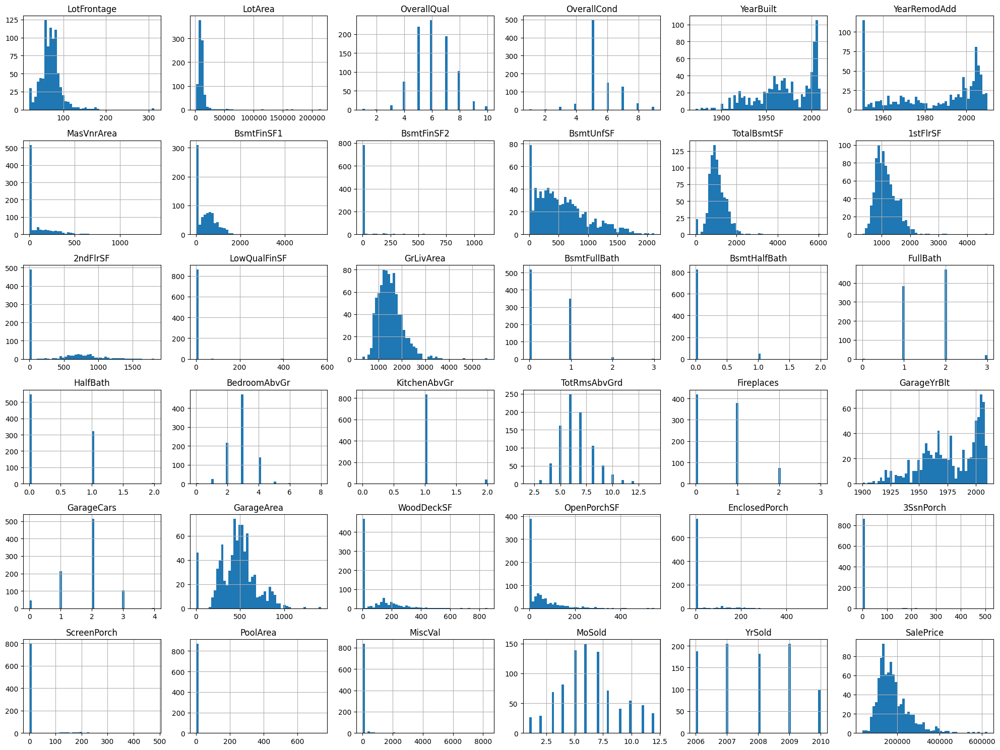

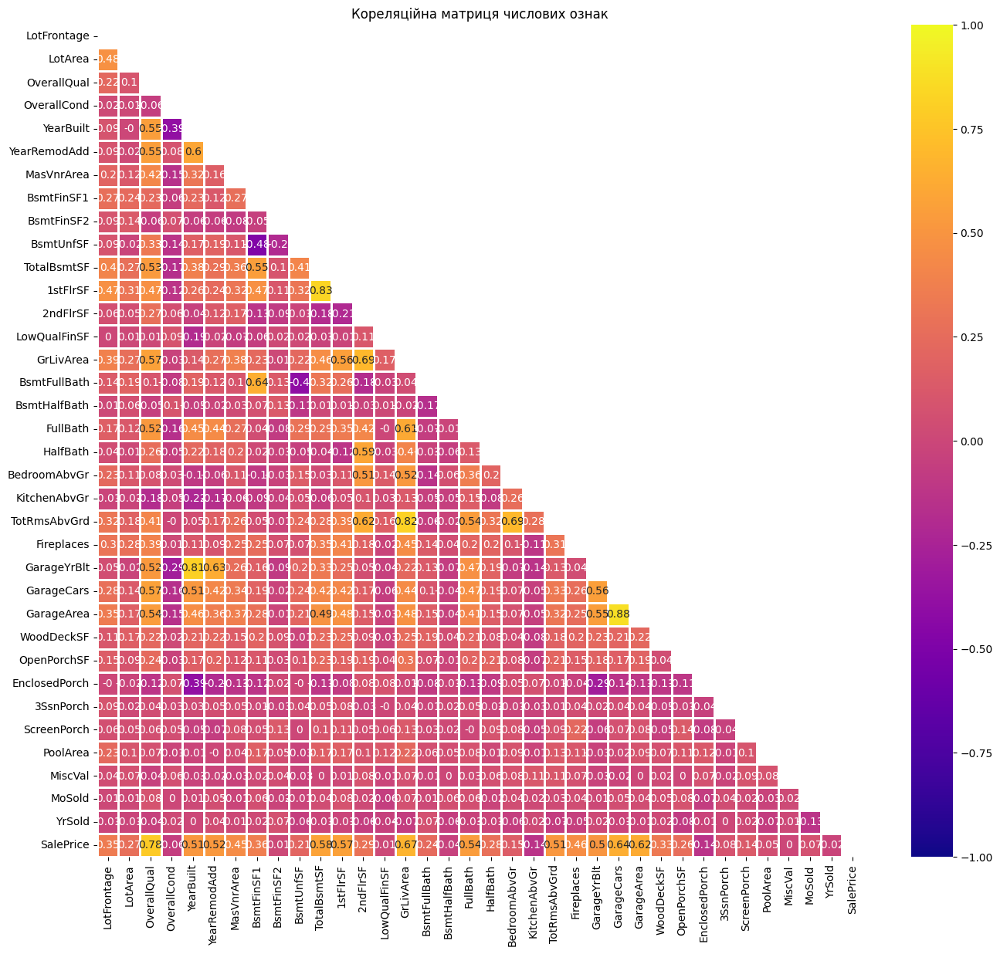

Топ-10 ознак, що найсильніше корелюють з SalePrice:
SalePrice       1.000000
OverallQual     0.781592
GrLivArea       0.665931
GarageCars      0.636458
GarageArea      0.615012
TotalBsmtSF     0.577081
1stFlrSF        0.574447
FullBath        0.535206
YearRemodAdd    0.519089
TotRmsAbvGrd    0.511087
YearBuilt       0.506321
Name: SalePrice, dtype: float64

Пари ознак із високою кореляцією (> 0.75):
1stFlrSF та TotalBsmtSF: 0.83
TotRmsAbvGrd та GrLivArea: 0.82
GarageYrBlt та YearBuilt: 0.81
GarageArea та GarageCars: 0.88
SalePrice та OverallQual: 0.78


In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

train_df[num_cols].hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

def corr_mat(df, cols):
    corr = df[cols].corr().round(2)
    f, ax = plt.subplots(figsize=(16, 14))
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, center=0,
                cmap="plasma", square=False, lw=1, annot=True, cbar=True)
    plt.title('Кореляційна матриця числових ознак')
    plt.show()

corr_mat(train_df, num_cols)

corr_matrix = train_df[num_cols].corr()
print("Топ-10 ознак, що найсильніше корелюють з SalePrice:")
print(corr_matrix['SalePrice'].sort_values(ascending=False).head(11))

print("\nПари ознак із високою кореляцією (> 0.75):")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            print(f"{corr_matrix.columns[i]} та {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")

                skew  zero_share
MiscVal        17.29        0.96
PoolArea       15.49        1.00
LotArea        11.04        0.00
3SsnPorch       9.59        0.98
LowQualFinSF    9.21        0.98
BsmtFinSF2      4.33        0.89
KitchenAbvGr    4.05        0.00
ScreenPorch     4.02        0.91
BsmtHalfBath    3.88        0.94
EnclosedPorch   3.39        0.87
LotFrontage     2.55        0.00
OpenPorchSF     2.36        0.44
MasVnrArea      2.24        0.58
BsmtFinSF1      2.15        0.31
TotalBsmtSF     2.09        0.03
1stFlrSF        1.65        0.00
WoodDeckSF      1.61        0.53
GrLivArea       1.50        0.00
BsmtUnfSF       0.85        0.08
2ndFlrSF        0.79        0.56


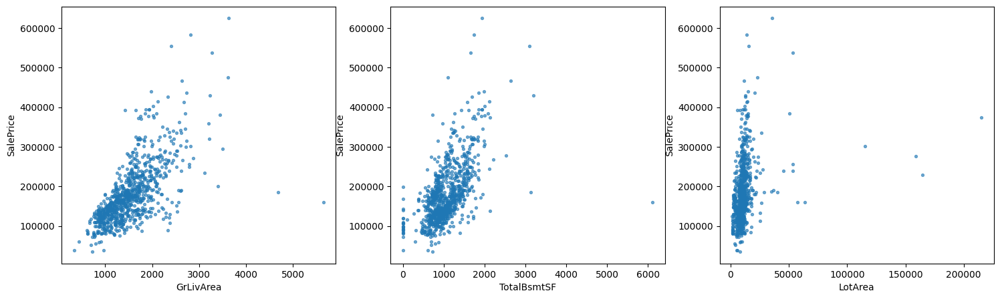

In [176]:
from scipy.stats import skew

base_num = train_df.select_dtypes(include=[np.number]).columns.drop("SalePrice")
diagnostics = pd.DataFrame({
    "skew": train_df[base_num].apply(skew),
    "zero_share": (train_df[base_num] == 0).mean(),
}).sort_values("skew", key=abs, ascending=False)
print(diagnostics.head(20).round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["GrLivArea", "TotalBsmtSF", "LotArea"]):
    ax.scatter(train_df[col], train_df["SalePrice"], s=8, alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
plt.show()

### Обробка викидів

Викиди обираємо за змістом, а не за статистичним порогом (у цьому випадку було б позначено викидами значну частину природно скошених ознак (LotArea, LotFrontage, MasVnrArea)).

Видаляємо (лише з train): два великих, але дешевих будинки. На діаграмі GrLivArea проти SalePrice два будинки (4700 і 5600 м2) коштують 160-185 тисяч і лежать далеко від загальної залежності - більша площа, вища ціна. Між ними і рештою є розрив у площі. Ті самі будинки видно на графіку TotalBsmtSF (3100 і 6100 м2). Обидва мають SaleCondition = Partial, тобто нетиповий тип продажу, тому їхня ціна, скоріше за все, не відображає площу. Це проблема, зайвий шум, а не реальний приклад залежності. Модель мінімізує квадрат помилки, тому дві такі точки сильно змістять лінію регресії. Крім того, ці рядки створюють значну частину перекосу в GrLivArea, TotalBsmtSF, BsmtFinSF1 та LotFrontage.

Залишаємо, але трансформуємо: великі ділянки (LotArea > 100 тис. за м2).
Чотири ділянки мають ціни 230-375 тис., у межах нормального діапазону, тобто це реальні великі ділянки, а не помилки. Якщо ми їх видалимо, то позбавимо модель такого типу об'єктів. Проблема лише в довгому хвості (skew 11), який вирішується логарифмом.

val і test не чіпаємо, бо вони імітують реальні дані, їх видалення зробило б оцінку штучно оптимістичною.

In [177]:
large_cheap = (train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 300_000)
print(train_df.loc[large_cheap, ["GrLivArea", "TotalBsmtSF", "SalePrice", "OverallQual"] + [c for c in train_df if c.startswith("SaleCondition_")]])

train_df = train_df.loc[~large_cheap].copy()
print("Видалено:", large_cheap.sum(), "| лишилось:", len(train_df))

      GrLivArea  TotalBsmtSF  SalePrice  OverallQual  SaleCondition_AdjLand  \
523        4676         3138     184750           10                  False   
1298       5642         6110     160000           10                  False   

      SaleCondition_Alloca  SaleCondition_Family  SaleCondition_Normal  \
523                  False                 False                 False   
1298                 False                 False                 False   

      SaleCondition_Partial  
523                    True  
1298                   True  
Видалено: 2 | лишилось: 874


### Інженерія ознак

З кореляційної матриці беремо пари ознак із кореляцією понад 0.75. Вони несуть майже однакову інформацію, тому лишаємо одну з пари:

- GarageArea та GarageCars (0.88): лишаємо GarageCars, бо вона сильніше корелює з SalePrice (0.64 проти 0.62)
- TotRmsAbvGrd та GrLivArea (0.82): прибираємо TotRmsAbvGrd (0.51 проти 0.67 з SalePrice), інформація вже міститься в площі
- GarageYrBlt та YearBuilt (0.81): прибираємо GarageYrBlt, бо для будинків без гаража її значення було вигадане імпутацією
- 1stFlrSF та TotalBsmtSF (0.83): GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF і TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF виконуються для всіх рядків. Якщо лишити суму разом із доданками, одна з колонок стає зайвою, а ваги лінійної регресії неоднозначними, тому їх інтерпретація втрачає сенс. Лишаємо суми, а 1stFlrSF, 2ndFlrSF, LowQualFinSF, BsmtUnfSF прибираємо.

+ нова ознака TotalBath (повні ванни + 0.5 за напівванну, включно з підвалом) замінює 4 колонки. Її кореляція з SalePrice (0.62) вища за кожну з чотирьох (найвпливовіша, FullBath, дає 0.54).

Ознаки з понад 95% нулів (PoolArea, MiscVal, 3SsnPorch, за таблицею skew і zero_share) прибираємо: ненульових значень у train лише кілька, і модель підлаштовується під окремі будинки, а не знаходить закономірність.

In [178]:
for d in (train_df, val_df, test_df):
    d["TotalBath"] = d["FullBath"] + 0.5 * d["HalfBath"] + d["BsmtFullBath"] + 0.5 * d["BsmtHalfBath"]

bath_cols = ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]
print("TotalBath:", round(train_df["TotalBath"].corr(train_df["SalePrice"]), 3),
      {c: round(train_df[c].corr(train_df["SalePrice"]), 3) for c in bath_cols})

drop_cols = ["GarageArea", "TotRmsAbvGrd", "GarageYrBlt",
             "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "BsmtUnfSF",
             *bath_cols,
             "PoolArea", "MiscVal", "3SsnPorch"]
for d in (train_df, val_df, test_df):
    d.drop(columns=drop_cols, inplace=True)
print("Колонок лишилось:", train_df.shape[1])

TotalBath: 0.621 {'FullBath': np.float64(0.538), 'HalfBath': np.float64(0.28), 'BsmtFullBath': np.float64(0.237), 'BsmtHalfBath': np.float64(-0.04)}
Колонок лишилось: 233


Трансформація скошених ознак: у скошеної ознаки є довгий хвіст рідкісних дуже великих значень, які після стандартизації мають непропорційно великий вплив. Логарифмуємо неперервні ознаки площі з |skew| > 1 на train: log1p стискає хвіст і коректно обробляє нуль. Список колонок обираємо за train, сама трансформація детермінована і застосовується до всіх трьох сплітів.

Після видалення двох викидів GrLivArea, TotalBsmtSF і BsmtFinSF1 перестали бути скошеними і лишилися без змін, тобто основну частину їхнього перекосу створювали саме ті два рядки. Для решти skew суттєво зменшився (наприклад, LotArea з 11.4 до 0.0). BsmtFinSF2 лишилась скошеною: майже 90% її значень нулі, а логарифм нулі не змінює.

In [179]:
from scipy.stats import skew

log_candidates = ["LotArea", "LotFrontage", "GrLivArea", "TotalBsmtSF", "BsmtFinSF1",
                  "BsmtFinSF2", "MasVnrArea", "WoodDeckSF", "OpenPorchSF"]
log_cols = [c for c in log_candidates if abs(skew(train_df[c])) > 1]
skew_before = train_df[log_cols].apply(skew)

for d in (train_df, val_df, test_df):
    d[log_cols] = np.log1p(d[log_cols])

print(pd.DataFrame({"before": skew_before, "after": train_df[log_cols].apply(skew)}).round(2))

             before  after
LotArea       11.43   0.02
LotFrontage    1.89  -0.77
BsmtFinSF2     4.32   2.66
MasVnrArea     2.24   0.43
WoodDeckSF     1.61   0.21
OpenPorchSF    2.35  -0.04


Рідкісні категорії: після кодування категорій у дамі-колонки деякі з них містять лише кілька одиниць значень (буквально 10 значень на 850+ записів). Модель не може надійно навчитись на такій кількості прикладів, а після стандартизації єдина одиниця перетворюється на значення, що у десятки разів перевищує типове. Тому такі колонки прибираємо за train і застосовуємо те саме до val і test.

In [180]:
dummy_cols = [c for c in train_df.columns if train_df[c].dtype == bool]
rare_dummies = [c for c in dummy_cols if train_df[c].sum() < 10]

for d in (train_df, val_df, test_df):
    d.drop(columns=rare_dummies, inplace=True)
print("Прибрано рідкісних категорій:", len(rare_dummies), "| колонок лишилось:", train_df.shape[1])

Прибрано рідкісних категорій: 64 | колонок лишилось: 169


## 2.2 Baseline: множинна лінійна регресія

### Підготовка X і y

In [181]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

feature_cols = [c for c in train_df.columns if c != "SalePrice"]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols].astype(float))
X_val = scaler.transform(val_df[feature_cols].astype(float))
X_test = scaler.transform(test_df[feature_cols].astype(float))

price_train = train_df["SalePrice"].values
price_val = val_df["SalePrice"].values
price_test = test_df["SalePrice"].values

y_train = np.log1p(price_train)
y_val = np.log1p(price_val)
y_test = np.log1p(price_test)

print("Skew SalePrice:", round(skew(price_train), 2), "-> після log1p:", round(skew(y_train), 2))
print("Форма X_train:", X_train.shape)

Skew SalePrice: 1.57 -> після log1p: 0.09
Форма X_train: (874, 168)


In [182]:
def to_tensor(X, y):
    return (
        torch.tensor(X, dtype=torch.float32).to(device),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device),
    )

x_train_t, y_train_t = to_tensor(X_train, y_train)
x_val_t, y_val_t = to_tensor(X_val, y_val)
x_test_t, y_test_t = to_tensor(X_test, y_test)

### Тренування

In [183]:
from torch.utils.tensorboard import SummaryWriter

N_EPOCHS = 1000
LEARNING_RATE = 0.01

set_seed()
n_features = X_train.shape[1]
linear_model = torch.nn.Linear(in_features=n_features, out_features=1).to(device)
optimizer = torch.optim.SGD(linear_model.parameters(), lr=LEARNING_RATE)
loss_fn = torch.nn.MSELoss()
writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, "linear"))

train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    linear_model.train()
    optimizer.zero_grad()
    loss = loss_fn(linear_model(x_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    linear_model.eval()
    with torch.no_grad():
        val_loss = loss_fn(linear_model(x_val_t), y_val_t).item()
    val_losses.append(val_loss)

    writer.add_scalar("Loss/train", loss.item(), epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    if epoch % 100 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss:.4f}")

writer.close()

epoch    0  train_loss=144.4587  val_loss=149.4321
epoch  100  train_loss=2.5599  val_loss=3.1729
epoch  200  train_loss=0.0590  val_loss=0.1282
epoch  300  train_loss=0.0122  val_loss=0.0337
epoch  400  train_loss=0.0101  val_loss=0.0255
epoch  500  train_loss=0.0094  val_loss=0.0235
epoch  600  train_loss=0.0091  val_loss=0.0226
epoch  700  train_loss=0.0088  val_loss=0.0221
epoch  800  train_loss=0.0087  val_loss=0.0216
epoch  900  train_loss=0.0086  val_loss=0.0213
epoch  999  train_loss=0.0085  val_loss=0.0209


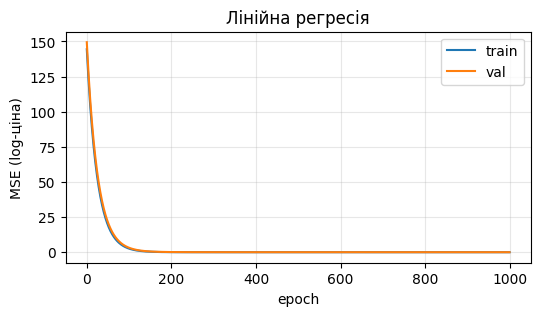

In [184]:
plt.figure(figsize=(6, 3))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch"); plt.ylabel("MSE (log-ціна)"); plt.title("Лінійна регресія")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Тести метрик

In [185]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linear_model.eval()
with torch.no_grad():
    log_pred = linear_model(x_test_t).cpu().numpy().flatten()

price_pred = np.expm1(log_pred)
baseline_pred = np.full(len(price_test), price_train.mean())

results = {}

def report(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{name:10s}  MSE={mse:,.0f}  RMSE={rmse:,.0f}  MAE={mae:,.0f}  R2={r2:.4f}")

report(price_test, baseline_pred, "baseline")
report(price_test, price_pred, "linear")

baseline    MSE=4,942,413,543  RMSE=70,302  MAE=54,319  R2=-0.0106
linear      MSE=503,624,352  RMSE=22,442  MAE=17,615  R2=0.8970


In [186]:
weights = linear_model.weight.detach().cpu().numpy().flatten()
weight_df = pd.DataFrame({"feature": feature_cols, "weight": weights})
weight_df = weight_df.reindex(weight_df["weight"].abs().sort_values(ascending=False).index)
print(weight_df.head(10).to_string(index=False))

MODELS_DIR = os.path.join(LAB_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)
torch.save(linear_model.state_dict(), os.path.join(MODELS_DIR, "linear.pt"))

          feature    weight
        GrLivArea  0.118002
BsmtFinType2_None  0.083431
      OverallQual  0.065693
       BsmtFinSF2  0.057377
        YearBuilt  0.055085
 BsmtFinType2_Unf  0.051580
   MSSubClass_190 -0.051427
  GarageQual_None -0.050797
      MSZoning_RL  0.048810
          LotArea  0.038286


## 2.3 Нейромережі

Перша архітектура:
- nn_v1: 168 -> 64 -> 32 -> 1 (два приховані шари), 12 929 параметрів
Друга архітектура:
- nn_v2: 168 -> 128 -> 64 -> 32 -> 1 (три приховані шари), 32 001 параметр

Параметри шару: входи × виходи + зміщення, наприклад Linear(168, 64) = 168·64 + 64 = 10 816.

Оптимізатор Adam (lr = 0.01) + фунеція втрати MSE, 200 епох, однакові для обох, щоб була саме архітектурна різниця. Мережі стартуватимуть з "середної ціни" (як baseline) і вчитимуть лише відхилення.

### Підготовка

In [187]:
y_mean = float(y_train.mean())

def train_model(model, run_name, lr=0.01, n_epochs=200, optimizer_cls=torch.optim.Adam):
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, run_name))
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(x_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(x_val_t), y_val_t).item()
        val_losses.append(val_loss)

        writer.add_scalar("Loss/train", loss.item(), epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)

        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:4d}  train_loss={loss.item():.4f}  val_loss={val_loss:.4f}")

    writer.close()
    return train_losses, val_losses

def plot_curves(train_losses, val_losses, title):
    plt.figure(figsize=(6, 3))
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("epoch"); plt.ylabel("MSE (log-ціна)"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

def evaluate(model, name):
    model.eval()
    with torch.no_grad():
        log_pred = model(x_test_t).cpu().numpy().flatten()
    report(price_test, np.expm1(log_pred), name)

### Тренування першої моделі

Параметрів: 12929
epoch    0  train_loss=0.1655  val_loss=0.0924
epoch   20  train_loss=0.0069  val_loss=0.0242
epoch   40  train_loss=0.0027  val_loss=0.0286
epoch   60  train_loss=0.0012  val_loss=0.0333
epoch   80  train_loss=0.0006  val_loss=0.0364
epoch  100  train_loss=0.0003  val_loss=0.0389
epoch  120  train_loss=0.0002  val_loss=0.0399
epoch  140  train_loss=0.0001  val_loss=0.0408
epoch  160  train_loss=0.0001  val_loss=0.0413
epoch  180  train_loss=0.0001  val_loss=0.0415
epoch  199  train_loss=0.0000  val_loss=0.0415


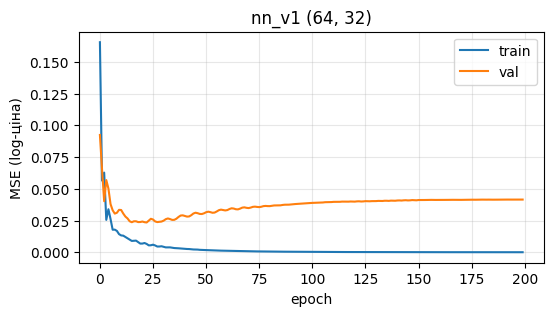

nn_v1_13k_params  MSE=1,104,540,032  RMSE=33,235  MAE=24,674  R2=0.7741


In [188]:
set_seed()
nn_v1 = torch.nn.Sequential(
    torch.nn.Linear(n_features, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1),
).to(device)
nn_v1[-1].bias.data.fill_(y_mean)
print("Параметрів:", sum(p.numel() for p in nn_v1.parameters()))

v1_train, v1_val = train_model(nn_v1, "nn_v1_13k_params")
plot_curves(v1_train, v1_val, "nn_v1 (64, 32)")
evaluate(nn_v1, "nn_v1_13k_params")
torch.save(nn_v1.state_dict(), os.path.join(MODELS_DIR, "nn_v1.pt"))

### Тренування другої моделі

Параметрів: 32001
epoch    0  train_loss=0.1488  val_loss=0.0826
epoch   20  train_loss=0.0126  val_loss=0.0360
epoch   40  train_loss=0.0048  val_loss=0.0304
epoch   60  train_loss=0.0023  val_loss=0.0325
epoch   80  train_loss=0.0010  val_loss=0.0351
epoch  100  train_loss=0.0004  val_loss=0.0371
epoch  120  train_loss=0.0002  val_loss=0.0381
epoch  140  train_loss=0.0001  val_loss=0.0387
epoch  160  train_loss=0.0000  val_loss=0.0395
epoch  180  train_loss=0.0000  val_loss=0.0405
epoch  199  train_loss=0.0000  val_loss=0.0395


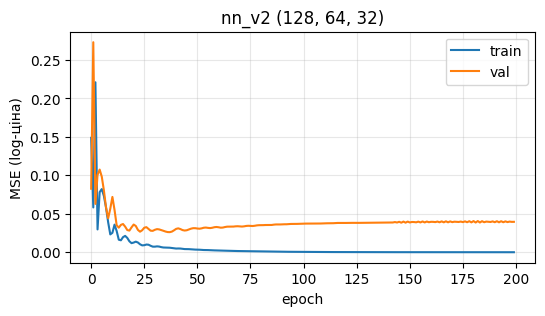

nn_v2_32k_params  MSE=1,125,757,824  RMSE=33,552  MAE=23,228  R2=0.7698


In [189]:
set_seed()
nn_v2 = torch.nn.Sequential(
    torch.nn.Linear(n_features, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1),
).to(device)
nn_v2[-1].bias.data.fill_(y_mean)
print("Параметрів:", sum(p.numel() for p in nn_v2.parameters()))

v2_train, v2_val = train_model(nn_v2, "nn_v2_32k_params")
plot_curves(v2_train, v2_val, "nn_v2 (128, 64, 32)")
evaluate(nn_v2, "nn_v2_32k_params")
torch.save(nn_v2.state_dict(), os.path.join(MODELS_DIR, "nn_v2.pt"))

## 2.4 Підбір гіперпараметрів

За базу беремо nn_v1m бо вона показує себе на рівні з nn_v2, але має майже в 2,5 раза менше параметрів, тому в теорії вона вигідніше та ефективніше,а більша кількість параметрів не має сенсу для нашого датасета. Поки, що обидві моделі перенавчаються: train loss прямує до нуля, а val loss після 20-50 епох починає рости. Змінюємо по одному гіперпараметру за раз (lr підбираємо потроху, але я це я рахую як один гіперпараметр, а не кілька), решта, окрім змінюваного, лишається як у nn_v1

In [190]:
def make_nn_v1():
    set_seed()
    model = torch.nn.Sequential(
        torch.nn.Linear(n_features, 64),
        torch.nn.ReLU(),
        torch.nn.Linear(64, 32),
        torch.nn.ReLU(),
        torch.nn.Linear(32, 1),
    ).to(device)
    model[-1].bias.data.fill_(y_mean)
    return model

### Тест 1: кількість епох така, на якій ми зупиняємося з мінімальним val loss

Мінімум val у nn_v1 на епосі 23 | val_loss = 0.0235
epoch    0  train_loss=0.1655  val_loss=0.0924
epoch   20  train_loss=0.0069  val_loss=0.0242
epoch   22  train_loss=0.0066  val_loss=0.0235


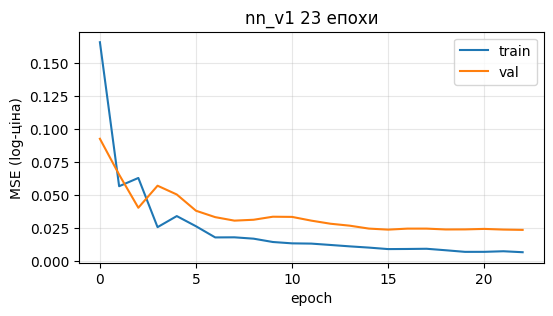

nn_v1_epochs_23  MSE=523,768,320  RMSE=22,886  MAE=16,846  R2=0.8929


In [191]:
best_epoch = int(np.argmin(v1_val)) + 1
print("Мінімум val у nn_v1 на епосі", best_epoch, "| val_loss =", round(min(v1_val), 4))

name = f"nn_v1_epochs_{best_epoch}"
nn_v1_epochs = make_nn_v1()
train_losses, val_losses = train_model(nn_v1_epochs, name, n_epochs=best_epoch)
plot_curves(train_losses, val_losses, f"nn_v1 {best_epoch} епохи")
evaluate(nn_v1_epochs, name)
torch.save(nn_v1_epochs.state_dict(), os.path.join(MODELS_DIR, "nn_v1_epochs.pt"))

### Тест 2: lr 0.01 -> 0.001

epoch    0  train_loss=0.1655  val_loss=0.1899
epoch   20  train_loss=0.0202  val_loss=0.0361
epoch   40  train_loss=0.0091  val_loss=0.0292
epoch   60  train_loss=0.0053  val_loss=0.0273
epoch   80  train_loss=0.0035  val_loss=0.0266
epoch  100  train_loss=0.0024  val_loss=0.0268
epoch  120  train_loss=0.0016  val_loss=0.0272
epoch  140  train_loss=0.0011  val_loss=0.0277
epoch  160  train_loss=0.0008  val_loss=0.0283
epoch  180  train_loss=0.0006  val_loss=0.0286
epoch  199  train_loss=0.0004  val_loss=0.0288


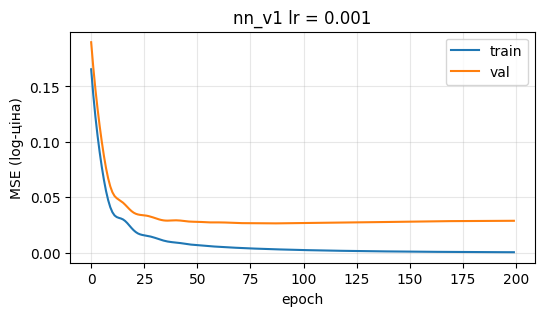

nn_v1_lr_change  MSE=582,907,456  RMSE=24,143  MAE=17,125  R2=0.8808


In [192]:
nn_v1_lr = make_nn_v1()
train_losses, val_losses = train_model(nn_v1_lr, "nn_v1_lr_change", lr=0.001)
plot_curves(train_losses, val_losses, "nn_v1 lr = 0.001")
evaluate(nn_v1_lr, "nn_v1_lr_change")
torch.save(nn_v1_lr.state_dict(), os.path.join(MODELS_DIR, "nn_v1_lr.pt"))

### Тест 3: Adam -> SGD

epoch    0  train_loss=0.1655  val_loss=0.2141
epoch   20  train_loss=0.1351  val_loss=0.1784
epoch   40  train_loss=0.1152  val_loss=0.1561
epoch   60  train_loss=0.0977  val_loss=0.1364
epoch   80  train_loss=0.0814  val_loss=0.1176
epoch  100  train_loss=0.0671  val_loss=0.1005
epoch  120  train_loss=0.0554  val_loss=0.0858
epoch  140  train_loss=0.0467  val_loss=0.0742
epoch  160  train_loss=0.0405  val_loss=0.0657
epoch  180  train_loss=0.0363  val_loss=0.0597
epoch  199  train_loss=0.0335  val_loss=0.0556


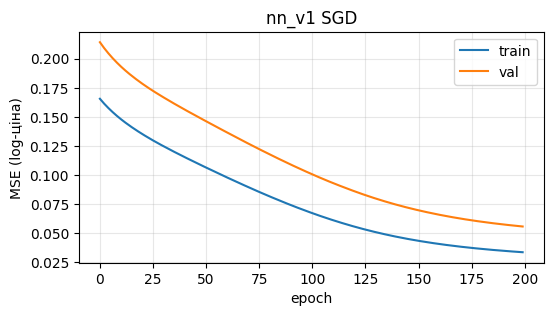

nn_v1_sgd   MSE=1,350,415,872  RMSE=36,748  MAE=25,643  R2=0.7239


In [193]:
nn_v1_sgd = make_nn_v1()
train_losses, val_losses = train_model(nn_v1_sgd, "nn_v1_sgd", optimizer_cls=torch.optim.SGD)
plot_curves(train_losses, val_losses, "nn_v1 SGD")
evaluate(nn_v1_sgd, "nn_v1_sgd")
torch.save(nn_v1_sgd.state_dict(), os.path.join(MODELS_DIR, "nn_v1_sgd.pt"))

## 2.5 Порівняння

#### Найкраща модель

Найкраща за основними метриками лінійна регресія: R2 близько 0.9, RMSE близько 22400. Нейромережа nn_v1_epochs_23 дуже близька: R2 близько 0.89, RMSE близько 22900. Тест складається лише з 292 будинків, тож така різниця, скоріше за все, в межах випадкових коливань. Обидві моделі значно кращі за baseline (простий прогноз середньої ціни), у якого RMSE близько 70300, помилка менша в 3 рази.

#### Чи виправдала себе нейромережа порівняно з лінійною регресією?

Ні. Найкраща нейромережа лише зрівнялася з лінійною регресією, але не перевершила її за R2 і RMSE, при цьому вона кратно складніша, 12929 параметрів проти 169. Скоріше за все це через те, що мало даних (874 рядки в train), а залежність логарифма ціни від ознак, ймовірно, близька до лінійної, тому нелінійній моделі нема що вчити понад те, що вже вчить лінійна модель. Мережа з надлишком параметрів швидко запам'ятовує train: train loss прямує до нуля, а val loss росте.

#### Що зі змін гіперпараметрів дало найбільший ефект?

Найбільший ефект дало зменшення кількість епох. Зупинка навчання на епосі з мінімальним val loss сильно підняла R2 з близько 0.75 до 0.89 і зменшила RMSE з 33 200 до 22 900. На другому місці менший learning rate (в результаті це 0.001): R2 близько 0.88, RMSE близько 24150. Зміна архітектури майже нічого не дала: R2 близько 0.77, nn_v2 = 0.76, тобто глибша і ширша мережа не допомогла, вона вперлася так само у перенавчання. Заміна Adam на SGD погіршила результат, бо за 200 епох SGD із lr = 0.01 не встиг навчитись, оскільки train і val loss ще падали.


В результаті для цього датасета важливо вчасно зупинити навчання і не перенавчити модель.

In [194]:
results_df = pd.DataFrame(results).T.rename_axis("model").reset_index()
results_df = results_df.sort_values("R2", ascending=False)
results_df.to_csv(os.path.join(LAB_DIR, "results.csv"), index=False)

results_df.style.format({"MSE": "{:,.0f}", "RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R2": "{:.4f}"})

,model,MSE,RMSE,MAE,R2
1,linear,"503,624,352","22,442","17,615",0.8970
4,nn_v1_epochs_23,"523,768,320","22,886","16,846",0.8929
5,nn_v1_lr_change,"582,907,456","24,143","17,125",0.8808
2,nn_v1_13k_params,"1,104,540,032","33,235","24,674",0.7741
3,nn_v2_32k_params,"1,125,757,824","33,552","23,228",0.7698
6,nn_v1_sgd,"1,350,415,872","36,748","25,643",0.7239
0,baseline,"4,942,413,543","70,302","54,319",-0.0106


In [195]:
%load_ext tensorboard
%tensorboard --logdir {RUNS_DIR}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 36943), started 3:30:43 ago. (Use '!kill 36943' to kill it.)

<IPython.core.display.Javascript object>

---
## 3. Gradio-застосунок: порівняння всіх варіантів наживо

### Тема апки: перевірка чесної ціни

Вводиться 7 основних параметрів будинку (якість, площа, підвал, гараж, ванні, рік побудови, ділянка) і ціну з уявного оголошення. Решта ознак беруться як у типового будинку з train (медіана). Введені значення проходять ту саму стандартизацію, що й train.

Висновок базується на медіані прогнозів усіх моделей. Очікуваний діапазон навколо оцінки визначається за val (поріг, нижче якого лежить половина помилок лінійної моделі у відсотках (медіанна похибка)). Якщо ціна в оголошенні нижче діапазону, вона занижена, якщо вище, завищена, інакше - ціна нормальна. Графік показує прогнози всіх моделей, діапазон і ціну з оголошення.

**До уваги:** Невведені параметри (район, стан кухні тощо) беруться типовими, тому оцінка орієнтовна

In [196]:
!pip install -q gradio
import gradio as gr
import matplotlib.pyplot as plt

In [198]:
models = {
    "linear": linear_model,
    "nn_v1_2layers": nn_v1,
    "nn_v2_deeper": nn_v2,
    f"nn_v1_epochs_{best_epoch}": nn_v1_epochs,
    "nn_v1_lr_change": nn_v1_lr,
    "nn_v1_sgd": nn_v1_sgd,
}

inputs = [
    ("OverallQual", "Загальна якість (1-10)", 1),
    ("GrLivArea", "Житлова площа над землею, кв. фути", 10),
    ("TotalBsmtSF", "Площа підвалу, кв. фути", 10),
    ("GarageCars", "Місць у гаражі", 1),
    ("TotalBath", "Ванні кімнати (півванна = 0.5)", 0.5),
    ("YearBuilt", "Рік побудови", 1),
    ("LotArea", "Площа ділянки, кв. фути", 100),
]

typical_house = train_df[feature_cols].astype(float).median()

linear_model.eval()
with torch.no_grad():
    linear_val_price = np.expm1(linear_model(x_val_t).cpu().numpy().flatten())
error_margin = float(np.quantile(np.abs(linear_val_price - price_val) / price_val, 0.5))


def check_price(asking_price, *values):
    if not asking_price or asking_price <= 0:
        return "Введіть ціну з оголошення", None

    row = typical_house.copy()
    for (col, _, _), value in zip(inputs, values):
        row[col] = np.log1p(value) if col in log_cols else value
    x = scaler.transform(pd.DataFrame([row], columns=feature_cols))
    x = torch.tensor(x, dtype=x_val_t.dtype, device=x_val_t.device)

    prices = {}
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            prices[name] = float(np.expm1(model(x).item()))

    estimate = float(np.median(list(prices.values())))
    low, high = estimate * (1 - error_margin), estimate * (1 + error_margin)
    if asking_price > high:
        verdict = "Ціна завищена"
    elif asking_price < low:
        verdict = "Ціна занижена"
    else:
        verdict = "Ціна в межах очікуваного"

    text = (
        f"### {verdict}\n"
        f"Оцінка (медіана 6 моделей): ${estimate:,.0f}\n\n"
        f"Очікуваний діапазон (±{error_margin:.0%}): ${low:,.0f} - ${high:,.0f}"
    )

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.scatter(list(prices.values()), range(len(prices)), color="blue")
    ax.set_yticks(range(len(prices)))
    ax.set_yticklabels(list(prices.keys()))
    ax.axvspan(low, high, color="green", alpha=0.2, label="Очікуваний діапазон")
    ax.axvline(asking_price, color="red", label="Ціна з оголошення")
    ax.axvline(estimate, color="green", linestyle="--", label="Медіанна оцінка")
    ax.set_xlabel("Ціна, $")
    ax.legend()
    plt.close(fig)
    return text, fig


with gr.Blocks(title="Перевірка чесної ціни") as demo:
    gr.Markdown(
        "# Перевірка чесної ціни будинку\n"
        "Введіть параметри будинку і ціну з оголошення. "
        "Решта ознак беруться як у типового будинку з train."
    )
    asking_price = gr.Number(label="Ціна з оголошення, $", value=round(float(np.median(price_train)), -3))

    sliders = []
    for col, label, step in inputs:
        raw = np.expm1(train_df[col]) if col in log_cols else train_df[col]
        sliders.append(gr.Slider(
            minimum=int(np.floor(raw.min())),
            maximum=int(np.ceil(raw.max())),
            value=float(raw.median()),
            step=step,
            label=label,
        ))

    button = gr.Button("Перевірити ціну")
    verdict_output = gr.Markdown()
    plot_output = gr.Plot()
    button.click(check_price, inputs=[asking_price] + sliders, outputs=[verdict_output, plot_output])

demo.launch(share=True, height=1200)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8a7be3d871607509a3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу

У форму (https://forms.gle/8Dbc9zB8L5tsNuNEA) здати посилання на **публічний** репозиторій, який містить:

1. **Цей ноутбук з усіма виконаними пунктами**. Має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Файли всіх натренованих варіантів моделі** (2.2-2.4) — лінійна регресія + всі варіанти нейромережі, кожен окремим `.pt` файлом.
3. **Логи TensorBoard** — папка `runs/` з усіма прогонами, щоб можна було відкрити криві навчання, не перезапускаючи ноутбук.
4. **Таблицю результатів** — `results.csv` з порівнянням усіх варіантів (модель, MSE, RMSE, MAE, R² на test).
5. **Відео демонстрації TensorBoard & Gradio-застосунку** замість скріншотів цього разу: 60-90 секунд. На відео показуєте тренування і роботу моделей і коротко розповідаєте про цікаве (можливості, обмеження, труднощі тренування).
6. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
/lab2/nn_task.ipynb
/lab2/models/linear.pt
/lab2/models/nn_v1.pt
/lab2/models/nn_v2.pt
/lab2/models/...        (усі інші варіанти з 2.3-2.4)
/lab2/runs/*
/lab2/results.csv
/lab2/demo.mp4
```